In [2]:
from MHW_daily_calcs import *

import matplotlib.pyplot as plt
import matplotlib.colors as mcol
import cmocean

In [3]:
climyrs=[1993,2022]
#flist=[fnameCanESM5d(mdirC5,yyyy,mm,1,0) for yyyy in range(climyrs[0],climyrs[-1]+1)] 

In [4]:
yrlims=ylimlistobs[0]

In [5]:
halfwin=10
qtile=.9
L=5 # 5 days
smoothClim=True
smoothmethod='tri'
meth=smoothmethod
win=halfwin
smoothedClim=smoothClim

In [6]:
jj=60
ilead=5
window=win
delt=15
smoothedTrend=True
detr=True
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True) 

In [8]:
fin=fnameCanESMAnomByLead(workdir[L], climyrs[0], climyrs[-1], ilead, jj, smoothClim, False, smoothmethod, window,L,detrended=False)
print(fin)
print('smoothmethod:',smoothmethod)
fout=fnameCanESMDetrFitByLead(workdir[L], climyrs[0], climyrs[-1], ilead, jj, smoothClim,False,smoothmethod,window,L)
ff=xr.open_dataset(fin,decode_times={'reftime':time_coder,'leadtime':False})
ff

/fs/site7/eccc/crd/cccma/users/reo000/work/MHW_5d/byLead/anombylead_sclimtri10_cwao_canesm5.1p1bc-v20240611_hindcast_C1993_2022_l005_j060_ocean_5d_surface_tso.nc
smoothmethod: tri


<xarray.Dataset> Size: 1GB
Dimensions:   (reftime: 378, r: 20, lat: 60, lon: 360)
Coordinates:
  * reftime   (reftime) object 3kB 1993-01-01 00:00:00 ... 2024-06-01 00:00:00
  * r         (r) int64 160B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
  * lat       (lat) float64 480B -29.5 -28.5 -27.5 -26.5 ... 26.5 27.5 28.5 29.5
  * lon       (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
    leadtime  float64 8B ...
Data variables:
    sst_an    (reftime, r, lat, lon) float64 1GB ...
    time      (reftime) object 3kB ...

In [14]:
x0=cftime.date2num(ff.reftime.values,f'days since {climyrs[0]:04}-01-01')
data=ff.sst_an
istartlat=jj
lats=ff.lat.values
lons=ff.lon.values

data=np.asarray(data)
dshape=data.shape
N=dshape[0]
R=dshape[1]
X=np.concatenate([np.ones((R*N,1)),(x0.reshape((N,1))*np.ones((N,R))).reshape((R*N,-1))],1)
newdata = np.reshape(data,(R*N, np.prod(dshape, axis=0) // (R*N))).copy() # // is floor division; ensure copy

In [ ]:
    b=np.linalg.lstsq(X,newdata,rcond=None)[0] # res=np.sum((np.dot(X,b)-Y)**2)
    ydetr=newdata-np.dot(X,b)
    b=np.reshape(b,tuple([2]+list(dshape)[2:]))
    dsb=xr.Dataset(data_vars={'fit':(['b','lat','lon'],b),},
                   coords={'b':np.arange(0,2),
                           'lat':lats,
                           'lon':lons})
    dsb.to_netcdf(fout,mode='w')

In [ ]:
lsqfit_md_detrPooled_saveb(x0=ff.reftime.values,data=ff.sst_an,climyrs,ilead,istartlat=jj,lats=ff.lat.values,lons=ff.lon.values,fout)
ff.close()

In [7]:
lmax=int(215/L)
assert delt%L==0 # have not decided what to do otherwise
def leadbounds(l0,lmax,delt):
    return max(0,l0-int(delt/L)), min(lmax,l0+int(delt/L)+1)
flist=[fnameCanESMAnomByLead(workdir[L], climyrs[0],climyrs[-1],il,jj,smoothClim=smoothedClim,smoothTrend=smoothedTrend,meth=smoothmethod,win=window,L=L,detrended=detr) \
            for il in range(*leadbounds(ilead,lmax,delt))]
flist

['/fs/site7/eccc/crd/cccma/users/reo000/work/MHW_5d/byLeadDetr/anombylead_sclimtri10_DetrTrStri10_cwao_canesm5.1p1bc-v20240611_hindcast_C1993_2022_l002_j060_ocean_5d_surface_tso.nc',
 '/fs/site7/eccc/crd/cccma/users/reo000/work/MHW_5d/byLeadDetr/anombylead_sclimtri10_DetrTrStri10_cwao_canesm5.1p1bc-v20240611_hindcast_C1993_2022_l003_j060_ocean_5d_surface_tso.nc',
 '/fs/site7/eccc/crd/cccma/users/reo000/work/MHW_5d/byLeadDetr/anombylead_sclimtri10_DetrTrStri10_cwao_canesm5.1p1bc-v20240611_hindcast_C1993_2022_l004_j060_ocean_5d_surface_tso.nc',
 '/fs/site7/eccc/crd/cccma/users/reo000/work/MHW_5d/byLeadDetr/anombylead_sclimtri10_DetrTrStri10_cwao_canesm5.1p1bc-v20240611_hindcast_C1993_2022_l005_j060_ocean_5d_surface_tso.nc',
 '/fs/site7/eccc/crd/cccma/users/reo000/work/MHW_5d/byLeadDetr/anombylead_sclimtri10_DetrTrStri10_cwao_canesm5.1p1bc-v20240611_hindcast_C1993_2022_l006_j060_ocean_5d_surface_tso.nc',
 '/fs/site7/eccc/crd/cccma/users/reo000/work/MHW_5d/byLeadDetr/anombylead_sclimtri10_

In [8]:
fqout=fnameCanESMAnomQtile(workdir[L], climyrs[0], climyrs[-1], ilead, jj, qtile, detr,
                           smoothClim=smoothedClim,smoothTrend=smoothedTrend,meth=smoothmethod,win=window,delt=delt,L=L)
fqout

'/fs/site7/eccc/crd/cccma/users/reo000/work/MHW_5d/byLeadDetr/qtileDetrByLead_ClimStri10_TrStri10_cwao_CanESM5.1p1bc-v20240611_hindcast_C1993_2022_L005_delt15_j060_q0_90_ocean_5d_surface_tso.nc'

In [9]:
t0=dt.datetime(1993,1,1)
ff=xr.open_mfdataset(flist,combine='nested',concat_dim=['leadtime'],parallel=True,decode_times={'reftime':time_coder,'leadtime':False})
ff=ff.where((ff.reftime>=cftime.DatetimeNoLeap(climyrs[0],1,1))&(ff.reftime<cftime.DatetimeNoLeap(climyrs[-1]+1,1,1)),drop=True)
ff

<xarray.Dataset> Size: 9GB
Dimensions:   (leadtime: 7, reftime: 360, r: 20, lat: 60, lon: 360)
Coordinates:
  * leadtime  (leadtime) float64 56B 303.0 423.0 543.0 ... 783.0 903.0 1.023e+03
  * reftime   (reftime) object 3kB 1993-01-01 00:00:00 ... 2022-12-01 00:00:00
  * r         (r) int64 160B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
  * lat       (lat) float64 480B -29.5 -28.5 -27.5 -26.5 ... 26.5 27.5 28.5 29.5
  * lon       (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    sst_an    (leadtime, reftime, r, lat, lon) object 9GB dask.array<chunksize=(1, 360, 20, 60, 360), meta=np.ndarray>

In [10]:
fc=ff.sst_an.coarsen(reftime=12,boundary='pad').construct(reftime=('year','month'))                                                                                   #fc=fc.chunk({'lat':10,'lon':10})
sh=fc.shape
ql1=np.nan*np.ones((12,sh[-2],sh[-1]))

In [11]:
fc

<xarray.DataArray 'sst_an' (leadtime: 7, year: 30, month: 12, r: 20, lat: 60,
                            lon: 360)> Size: 9GB
dask.array<reshape, shape=(7, 30, 12, 20, 60, 360), dtype=object, chunksize=(1, 30, 12, 20, 60, 360), chunktype=numpy.ndarray>
Coordinates:
  * leadtime  (leadtime) float64 56B 303.0 423.0 543.0 ... 783.0 903.0 1.023e+03
    reftime   (year, month) object 3kB 1993-01-01 00:00:00 ... 2022-12-01 00:...
  * r         (r) int64 160B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
  * lat       (lat) float64 480B -29.5 -28.5 -27.5 -26.5 ... 26.5 27.5 28.5 29.5
  * lon       (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: year, month

In [ ]:
print(dt.datetime.now())
ii=0
pool1=fc.isel(month=ii).data.reshape((sh[0]*sh[1]*sh[3],sh[4],sh[5])).compute(scheduler='processes')#.rechunk((-1,10,10))
print(dt.datetime.now())
pool1

2026-08-19 17:31:18.996942


In [ ]:
ql1[ii,...]=da.apply_along_axis(np.nanquantile,0,pool1,qtile).compute(scheduler='processes')

In [ ]:
pool1

In [ ]:

print(fqout,flush=True)
dsqt=xr.Dataset(data_vars={'qt1':(['month','lat','lon'],ql1,{'long_name':f"{100*qtile}th percentile value"}),},
                           # 'qt2':(['month','lat','lon'],ql2,{'long_name':f"{100*qtile}th percentile value"}),},
               coords={'month':np.arange(0,12),
                       'lat':ff.lat,
                       'lon':ff.lon})
dsqt.to_netcdf(fqout,mode='w')
del dsqt; del fc; del ql1; del ql2; del pool1; #del pool2;
ff.close()

In [8]:
fnamout=fnameCanESMAnomByLead(workdir[L],climyrs[0],climyrs[-1],ilead,jj,smoothClim,smoothTrend=False,meth=smoothmethod,win=win,L=L,detrended=False)
ff= xr.open_dataset(fnamout,decode_times=False)

In [11]:
ff.leadtime.values

array(663.)

In [14]:
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
flist=[fnameCanESMAnom0(workdir[L],climyrs[0],climyrs[-1],yy,mm,smoothClim,smoothmethod,win,L) for yy in range(1993,2025) for mm in range(1,13) if yy<2024 or mm<=6]
ff= xr.open_mfdataset(flist,parallel=True,combine='nested',concat_dim='reftime',decode_times={'reftime':time_coder,'leadtime':False},
                                    preprocess=lambda ff: ff.isel(leadtime=ilead,lat=slice(jj,jj+60)))

In [16]:
ff.leadtime/24/5

<xarray.DataArray 'leadtime' ()> Size: 8B
array(5.525)
Coordinates:
    leadtime  float64 8B 663.0
Attributes:
    units:          hours
    long_name:      Time elapsed since the start of the forecast
    standard_name:  forecast_period

In [16]:
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
flist=[fnameCanESMAnom0(workdir[L],climyrs[0],climyrs[-1],yy,mm,smoothClim,smoothmethod,win,L) for yy in range(1993,2025) for mm in range(1,13) if yy<2024 or mm<=6]
fnamout=fnameCanESMAnomByLead(workdir[L],climyrs[0],climyrs[-1],ilead,jj,smoothClim,smoothTrend=False,meth=smoothmethod,win=win,L=L,detrended=False)
ff= xr.open_mfdataset(flist,parallel=True,combine='nested',concat_dim='reftime',decode_times={'reftime':time_coder,'leadtime':False},
                        preprocess=lambda ff: ff.isel(lat=slice(jj,jj+60)))

In [20]:
test=xr.open_dataset(flist[0])

/tmp/reo000/3684296/ipykernel_3972473/2736566377.py:1: FutureWarning: In a future version, xarray will not decode the variable 'leadtime' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  test=xr.open_dataset(flist[0])


In [22]:
flist[0]

'/fs/site7/eccc/crd/cccma/users/reo000/work/MHW_5d/anom/anom_sclimtri10_cwao_CanESM5.1p1bc-v20240611_hindcast_C1993_2022_SYr1993Mon01_ocean_5d_surface_tso.nc'

In [30]:
fnameclim=fnameCanESMClim(workdir[L],climyrs[0],climyrs[-1],1,False,smoothmethod,win,L)
clim=xr.open_dataset(fnameclim)
clim

/tmp/reo000/3684296/ipykernel_3972473/1515221804.py:2: FutureWarning: In a future version, xarray will not decode the variable 'leadtime' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  clim=xr.open_dataset(fnameclim)


<xarray.Dataset> Size: 22MB
Dimensions:   (leadtime: 43, lat: 180, lon: 360)
Coordinates:
  * leadtime  (leadtime) timedelta64[ns] 344B 2 days 15:00:00 ... 212 days 15...
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    tso       (leadtime, lat, lon) float64 22MB ...

In [33]:
flist=[fnameCanESM5d(mdirC5,yyyy,1,1,0) for yyyy in range(climyrs[0],climyrs[-1]+1)]
flist

['/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S1993010100_ocean_5d_surface_tso.nc',
 '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S1994010100_ocean_5d_surface_tso.nc',
 '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S1995010100_ocean_5d_surface_tso.nc',
 '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S1996010100_ocean_5d_surface_tso.nc',
 '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S1997010100_ocean_5d_surface_tso.nc',
 '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S1998010100_ocean_5d_surface_tso.nc',
 '/fs/site7/eccc

In [34]:
test=xr.open_dataset(flist[0])

/tmp/reo000/3684296/ipykernel_3972473/2736566377.py:1: FutureWarning: In a future version, xarray will not decode the variable 'leadtime' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  test=xr.open_dataset(flist[0])


In [35]:
test

<xarray.Dataset> Size: 446MB
Dimensions:   (lat: 180, bnds: 2, lon: 360, r: 20, leadtime: 43)
Coordinates:
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * leadtime  (leadtime) timedelta64[ns] 344B 2 days 15:00:00 ... 212 days 15...
    reftime   object 8B ...
Dimensions without coordinates: bnds, r
Data variables:
    lat_bnds  (lat, bnds) float64 3kB ...
    lon_bnds  (lon, bnds) float64 6kB ...
    tso       (r, leadtime, lat, lon) float64 446MB ...
Attributes: (12/21)
    comment:                  Produced by ECCC (Environment and Climate Chang...
    summary:                  Seasonal Forecast data produced by ECCC as its ...
    title:                    ECCC seasonal forecast model output prepared fo...
    forecast_type:            hindcast
    Conventions:              CF-1.6 C3S-0.1
    project:                  C3S Seasonal Forecast
    ...                       ...
    forecast_reference_time:  1993-01-01T00:00:00Z
    history:                  Sat Aug 31 04:30:30 2024: ncecat /space/hall5/s...
    data_licence:             1) GRANT OF LICENCE - The Government of Canada ...
    commit:                    
    creation_date:            2024-07-07T07:30:39Z
    NCO:                      netCDF Operators version 5.0.5 (Homepage = http...

In [18]:
ff.leadtime

<xarray.DataArray 'leadtime' (leadtime: 43)> Size: 344B
array([  63.,  183.,  303.,  423.,  543.,  663.,  783.,  903., 1023., 1143.,
       1263., 1383., 1503., 1623., 1743., 1863., 1983., 2103., 2223., 2343.,
       2463., 2583., 2703., 2823., 2943., 3063., 3183., 3303., 3423., 3543.,
       3663., 3783., 3903., 4023., 4143., 4263., 4383., 4503., 4623., 4743.,
       4863., 4983., 5103.])
Coordinates:
  * leadtime  (leadtime) float64 344B 63.0 183.0 303.0 ... 4.983e+03 5.103e+03
Attributes:
    units:          hours
    long_name:      Time elapsed since the start of the forecast
    standard_name:  forecast_period

In [14]:
663/24

27.625

In [ ]:
sst_an2=ff.sst_an.chunk({'reftime':ff.sst_an.shape[0],'r':20,'lat':30,'lon':360})
# fix time
reftime=[cftime.DatetimeNoLeap(yy,mm,1,0,0) for yy in range(1993,2025) for mm in range(1,13) if yy<2024 or mm<=6]
time=[cftime.DatetimeNoLeap(yy,mm,1,0,0)+dt.timedelta(hours=float(ff.leadtime.values)) \
            for yy in range(1993,2025) for mm in range(1,13) if yy<2024 or mm<=6]
dout=sst_an2.data.compute(scheduler='processes')
fout=xr.Dataset(data_vars={'sst_an':(['reftime','r','lat','lon'],dout),
                           'time':(['reftime',],time,{'long_name':'Real Time'})},
                coords={'reftime':reftime,
                        'r':np.arange(0,ff.sst_an.shape[1]),
                        'lat':ff.lat,
                        'lon':ff.lon})
mkdirs(fnamout)
print(fnamout)
fout.to_netcdf(fnamout,mode='w') # encoding={'sst_an': {'chunksizes': [Anom0.shape[0],1,20,360]}}
del sst_an2; del fout;
ff.close(); del ff;

In [26]:
mm=2
flist=[fnameCanESM5d(mdirC5,yyyy,mm,1,0) for yyyy in range(1993,2025) if yyyy<2024 or mm<=6] # stop at Jul 2024
flist

['/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S1993020100_ocean_5d_surface_tso.nc',
 '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S1994020100_ocean_5d_surface_tso.nc',
 '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S1995020100_ocean_5d_surface_tso.nc',
 '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S1996020100_ocean_5d_surface_tso.nc',
 '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S1997020100_ocean_5d_surface_tso.nc',
 '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S1998020100_ocean_5d_surface_tso.nc',
 '/fs/site7/eccc

In [29]:
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)

In [30]:
test=xr.open_dataset('/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S2018020100_ocean_5d_surface_tso.nc',decode_times={'reftime':time_coder,'leadtime':False})

In [33]:
test.reftime.values

array(cftime.DatetimeNoLeap(2018, 2, 1, 0, 0, 0, 0, has_year_zero=True),
      dtype=object)

In [ ]:
            fnameclim=fnameCanESMClim(workdir[L],climyrs[0],climyrs[-1],mm,smoothClim,smoothmethod,window,L)
            with LocalCluster(n_workers=ncpu-1,threads_per_worker=1) as cluster, Client(cluster) as client:
                with xr.open_mfdataset(flist,parallel=True,combine='nested',concat_dim='reftime',
                        decode_times={'reftime':time_coder,'leadtime':False},
                        chunks={'reftime':-1,'leadtime':-1,'r':-1,'lat':-1,'lon':-1}) as ff:

In [11]:
flist=[fnameCanESMAnom0(workdir[L],climyrs[0],climyrs[-1],yy,mm,smoothClim,smoothmethod,win,L) for yy in range(1993,2025) for mm in range(1,13) if yy<2024 or mm<=6]
fnamout=fnameCanESMAnomByLead(workdir[L],climyrs[0],climyrs[-1],ilead,jj,smoothClim,smoothTrend=False,meth=smoothmethod,win=win,L=L,detrended=False)

In [22]:
flist

['/fs/site7/eccc/crd/cccma/users/reo000/work/MHW_5d/anom/anom_sclimtri10_cwao_CanESM5.1p1bc-v20240611_hindcast_C1993_2022_SYr1993Mon01_ocean_5d_surface_tso.nc',
 '/fs/site7/eccc/crd/cccma/users/reo000/work/MHW_5d/anom/anom_sclimtri10_cwao_CanESM5.1p1bc-v20240611_hindcast_C1993_2022_SYr1993Mon02_ocean_5d_surface_tso.nc',
 '/fs/site7/eccc/crd/cccma/users/reo000/work/MHW_5d/anom/anom_sclimtri10_cwao_CanESM5.1p1bc-v20240611_hindcast_C1993_2022_SYr1993Mon03_ocean_5d_surface_tso.nc',
 '/fs/site7/eccc/crd/cccma/users/reo000/work/MHW_5d/anom/anom_sclimtri10_cwao_CanESM5.1p1bc-v20240611_hindcast_C1993_2022_SYr1993Mon04_ocean_5d_surface_tso.nc',
 '/fs/site7/eccc/crd/cccma/users/reo000/work/MHW_5d/anom/anom_sclimtri10_cwao_CanESM5.1p1bc-v20240611_hindcast_C1993_2022_SYr1993Mon05_ocean_5d_surface_tso.nc',
 '/fs/site7/eccc/crd/cccma/users/reo000/work/MHW_5d/anom/anom_sclimtri10_cwao_CanESM5.1p1bc-v20240611_hindcast_C1993_2022_SYr1993Mon06_ocean_5d_surface_tso.nc',
 '/fs/site7/eccc/crd/cccma/users/r

In [12]:
    ff= xr.open_mfdataset(flist,parallel=True,combine='nested',concat_dim='reftime',
                            preprocess=lambda ff: ff.isel(leadtime=ilead,lat=slice(jj,jj+60)),decode_times=False)

In [23]:
ff.reftime.values

array([    0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,   365,   365,   365,   365,   365,   365,
         365,   365,   365,   365,   365,   365,   730,   730,   730,
         730,   730,   730,   730,   730,   730,   730,   730,   730,
        1095,  1095,  1095,  1095,  1095,  1095,  1095,  1095,  1095,
        1095,  1095,  1095,  1460,  1460,  1460,  1460,  1460,  1460,
        1460,  1460,  1460,  1460,  1460,  1460,  1825,  1825,  1825,
        1825,  1825,  1825,  1825,  1825,  1825,  1825,  1825,  1825,
        2190,  2190,  2190,  2190,  2190,  2190,  2190,  2190,  2190,
        2190,  2190,  2190,  2555,  2555,  2555,  2555,  2555,  2555,
        2555,  2555,  2555,  2555,  2555,  2555,  2920,  2920,  2920,
        2920,  2920,  2920,  2920,  2920,  2920,  2920,  2920,  2920,
        3285,  3285,  3285,  3285,  3285,  3285,  3285,  3285,  3285,
        3285,  3285,  3285,  3650,  3650,  3650,  3650,  3650,  3650,
        3650,  3650,

In [13]:
    sst_an2=ff.sst_an.chunk({'reftime':ff.sst_an.shape[0],'r':20,'lat':30,'lon':360})

In [16]:
dout=sst_an2.compute(scheduler='processes')

In [19]:
dout.shape

(378, 20, 60, 360)

In [20]:
dout.reftime.values

array([    0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,   365,   365,   365,   365,   365,   365,
         365,   365,   365,   365,   365,   365,   730,   730,   730,
         730,   730,   730,   730,   730,   730,   730,   730,   730,
        1095,  1095,  1095,  1095,  1095,  1095,  1095,  1095,  1095,
        1095,  1095,  1095,  1460,  1460,  1460,  1460,  1460,  1460,
        1460,  1460,  1460,  1460,  1460,  1460,  1825,  1825,  1825,
        1825,  1825,  1825,  1825,  1825,  1825,  1825,  1825,  1825,
        2190,  2190,  2190,  2190,  2190,  2190,  2190,  2190,  2190,
        2190,  2190,  2190,  2555,  2555,  2555,  2555,  2555,  2555,
        2555,  2555,  2555,  2555,  2555,  2555,  2920,  2920,  2920,
        2920,  2920,  2920,  2920,  2920,  2920,  2920,  2920,  2920,
        3285,  3285,  3285,  3285,  3285,  3285,  3285,  3285,  3285,
        3285,  3285,  3285,  3650,  3650,  3650,  3650,  3650,  3650,
        3650,  3650,

In [17]:
dout

<xarray.DataArray 'sst_an' (reftime: 378, r: 20, lat: 60, lon: 360)> Size: 1GB
array([[[[ 1.19099548e-01, -9.16013273e-03, -1.02904101e-01, ...,
           4.29474330e-01,  3.10713742e-01,  2.04255150e-01],
         [ 7.08141448e-02,  1.50767708e-03, -5.66172651e-02, ...,
           3.47676190e-01,  2.24320196e-01,  1.31934638e-01],
         [ 1.52581283e-01,  1.08813509e-01,  4.62870814e-02, ...,
           3.15222324e-01,  2.15969153e-01,  1.72176698e-01],
         ...,
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]],

        [[ 1.96460889e+00,  1.71238680e+00,  1.51499751e+00, ...,
           2.58712051e+00,  2.45384424e+00,  2.18962502e+00],
         [ 1.79250146e+00,  1.60494853e+00,  1.48288164e+00, ...,
           2.54896556e+00,  2.34072187e+00,  2.02351636e+00],
         [ 1.54481761e+00,  1.48719333e+00,  1.42048447e+00, ...,
           2.27577988e+00,  2.02142722e+00,  1.71990161e+00],
...
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]],

        [[ 3.14949121e-01,  3.89120539e-01,  4.29660983e-01, ...,
           5.60662678e-01,  4.71170314e-01,  3.84058948e-01],
         [ 4.48816150e-01,  3.81302614e-01,  3.86774611e-01, ...,
           5.42502382e-01,  5.46306661e-01,  5.24196103e-01],
         [ 6.02908510e-01,  4.91758228e-01,  3.79498891e-01, ...,
           4.57911400e-01,  5.52478275e-01,  6.23333963e-01],
         ...,
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]]]],
      shape=(378, 20, 60, 360))
Coordinates:
  * reftime   (reftime) int64 3kB 0 0 0 0 0 0 ... 11315 11315 11315 11315 11315
  * lat       (lat) float64 480B -29.5 -28.5 -27.5 -26.5 ... 26.5 27.5 28.5 29.5
  * lon       (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
    leadtime  float64 8B 663.0
Dimensions without coordinates: r
Attributes:
    long_name:      Sea Surface Temperature
    standard_name:  sea_surface_temperature
    cell_methods:   leadtime: point
    units:          K
    grid_mapping:   hcrs
    postprocess:    5d time average, [(6,12,18,24),...]

In [ ]:
    # fix time
    reftime=[cftime.DatetimeNoLeap(yy,mm,1,0,0) for yy in range(1993,2025) for mm in range(1,13) if yy<2024 or mm<=6]
    time=[cftime.DatetimeNoLeap(yy,mm,1,0,0)+dt.timedelta(hours=float(ff.leadtime.values)) \
                for yy in range(1993,2025) for mm in range(1,13) if yy<2024 or mm<=6]
    dout=sst_an2.data.compute(scheduler='processes')

In [14]:
flist=[fnameOISSTGrid2(yrlims,L=L) for yrlims in ylimlistobs]
fg2=xr.open_mfdataset(flist,decode_times=True,parallel=True)
#    fg2=fg2.sel(time=slice(cftime.DatetimeNoLeap(climyrs[0],1,1),

In [15]:
fg2=fg2.where((fg2.time>=cftime.DatetimeNoLeap(climyrs[0],1,1))&(fg2.time<cftime.DatetimeNoLeap(climyrs[-1]+1,1,1)),drop=True)

In [16]:
fg2

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 2190, lat: 180, lon: 360)
Coordinates:
  * time     (time) object 18kB 1993-01-03 12:00:00 ... 2022-12-29 12:00:00
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    sst      (time, lat, lon) float32 568MB dask.array<chunksize=(611, 180, 360), meta=np.ndarray>
    ice      (time, lat, lon) float32 568MB dask.array<chunksize=(611, 180, 360), meta=np.ndarray>
    err      (time, lat, lon) float32 568MB dask.array<chunksize=(611, 180, 360), meta=np.ndarray>

In [ ]:
def OISST_anom_detr(climyrs,smoothClim=False, meth=None, win=1,L=1):
    for jj in range(0,180,60):
        flist=[fnameOISSTAnom(yrlims, climyrs, jj, smoothClim, meth, win,L) for yrlims in ylimlistobs]
        fanom=xr.open_mfdataset(flist,decode_times=False,parallel=True)
        sst_an=lsqfit_md_detr(fanom.sst_an.values)
        fout=fnameOISSTAnom([ylimlistobs[0][0],ylimlistobs[-1][-1]],climyrs, jj, smoothClim, meth, win,L,detrended=True)
        dsout=xr.Dataset(data_vars={'sst_an':(['time','lat','lon'],sst_an)},
                         coords={'time':fanom.time,
                                 'lat':fanom.lat,
                                 'lon':fanom.lon})
        dsout.to_netcdf(fout,mode='w')

In [7]:
flist=[fnameOISSTAnom(yrlims, climyrs, jj, smoothClim, meth, win,L) for yrlims in ylimlistobs]
fanom=xr.open_mfdataset(flist,parallel=True)
fanom

<xarray.Dataset> Size: 423MB
Dimensions:  (time: 2445, lat: 60, lon: 360)
Coordinates:
  * time     (time) object 20kB 1991-01-03 12:00:00 ... 2024-06-27 12:00:00
  * lat      (lat) float32 240B -29.5 -28.5 -27.5 -26.5 ... 26.5 27.5 28.5 29.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    sst_an   (time, lat, lon) float64 422MB dask.array<chunksize=(730, 60, 360), meta=np.ndarray>

In [9]:
flistD=[fnameOISSTAnom([1991,2024], climyrs, jj, smoothClim, meth, win,L,True)]
fanomD=xr.open_mfdataset(flistD,parallel=True)
fanomD

<xarray.Dataset> Size: 423MB
Dimensions:  (time: 2445, lat: 60, lon: 360)
Coordinates:
  * time     (time) object 20kB 1991-01-03 12:00:00 ... 2024-06-27 12:00:00
  * lat      (lat) float32 240B -29.5 -28.5 -27.5 -26.5 ... 26.5 27.5 28.5 29.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    sst_an   (time, lat, lon) float64 422MB dask.array<chunksize=(2445, 60, 360), meta=np.ndarray>

In [7]:
fanom2=fanom.sel(time=slice(cftime.DatetimeNoLeap(climyrs[0],1,1),cftime.DatetimeNoLeap(climyrs[-1],12,31,23,59,59)))
fanom2

<xarray.Dataset> Size: 378MB
Dimensions:  (time: 2190, lat: 60, lon: 360)
Coordinates:
  * time     (time) object 18kB 1993-01-03 12:00:00 ... 2022-12-29 12:00:00
  * lat      (lat) float32 240B -29.5 -28.5 -27.5 -26.5 ... 26.5 27.5 28.5 29.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    sst_an   (time, lat, lon) float64 378MB dask.array<chunksize=(584, 60, 360), meta=np.ndarray>

In [11]:
fclim0=xr.open_dataset('/fs/site7/eccc/crd/cccma/users/reo000/work/MHW_5d/OISST/climSST_oisst-avhrr-v02r01.regridded1x1g2.5d_C1993_2022.nc')
fclim1=xr.open_dataset('/fs/site7/eccc/crd/cccma/users/reo000/work/MHW_5d/OISST/climSST_smooth_tri10_oisst-avhrr-v02r01.regridded1x1g2.5d_C1993_2022.nc')

In [12]:
fclim1.yearday

<xarray.DataArray 'yearday' (yearday: 73)> Size: 584B
array([  1,   6,  11,  16,  21,  26,  31,  36,  41,  46,  51,  56,  61,  66,
        71,  76,  81,  86,  91,  96, 101, 106, 111, 116, 121, 126, 131, 136,
       141, 146, 151, 156, 161, 166, 171, 176, 181, 186, 191, 196, 201, 206,
       211, 216, 221, 226, 231, 236, 241, 246, 251, 256, 261, 266, 271, 276,
       281, 286, 291, 296, 301, 306, 311, 316, 321, 326, 331, 336, 341, 346,
       351, 356, 361])
Coordinates:
  * yearday  (yearday) int64 584B 1 6 11 16 21 26 31 ... 336 341 346 351 356 361

In [9]:
flist=[fnameOISSTGrid2(yrlims,L=L) for yrlims in ylimlistobs]
forig=xr.open_mfdataset(flist,parallel=True).sel(time=slice(cftime.DatetimeNoLeap(climyrs[0],1,1),cftime.DatetimeNoLeap(climyrs[-1],12,31,23,59,59)))
forig

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 2190, lat: 180, lon: 360)
Coordinates:
  * time     (time) object 18kB 1993-01-03 12:00:00 ... 2022-12-29 12:00:00
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    sst      (time, lat, lon) float32 568MB dask.array<chunksize=(584, 180, 360), meta=np.ndarray>
    ice      (time, lat, lon) float32 568MB dask.array<chunksize=(584, 180, 360), meta=np.ndarray>
    err      (time, lat, lon) float32 568MB dask.array<chunksize=(584, 180, 360), meta=np.ndarray>

In [10]:
fclim0

<xarray.Dataset> Size: 38MB
Dimensions:  (yearday: 73, lat: 180, lon: 360)
Coordinates:
  * yearday  (yearday) int64 584B 1 6 11 16 21 26 31 ... 336 341 346 351 356 361
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    sst      (yearday, lat, lon) float64 38MB ...

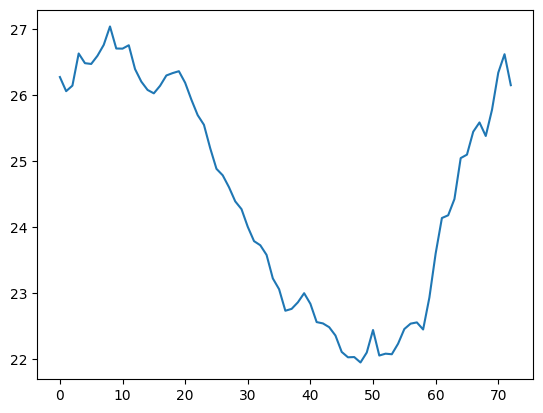

In [15]:
plt.plot(fclim0.sst.values[:,jj+5,180])

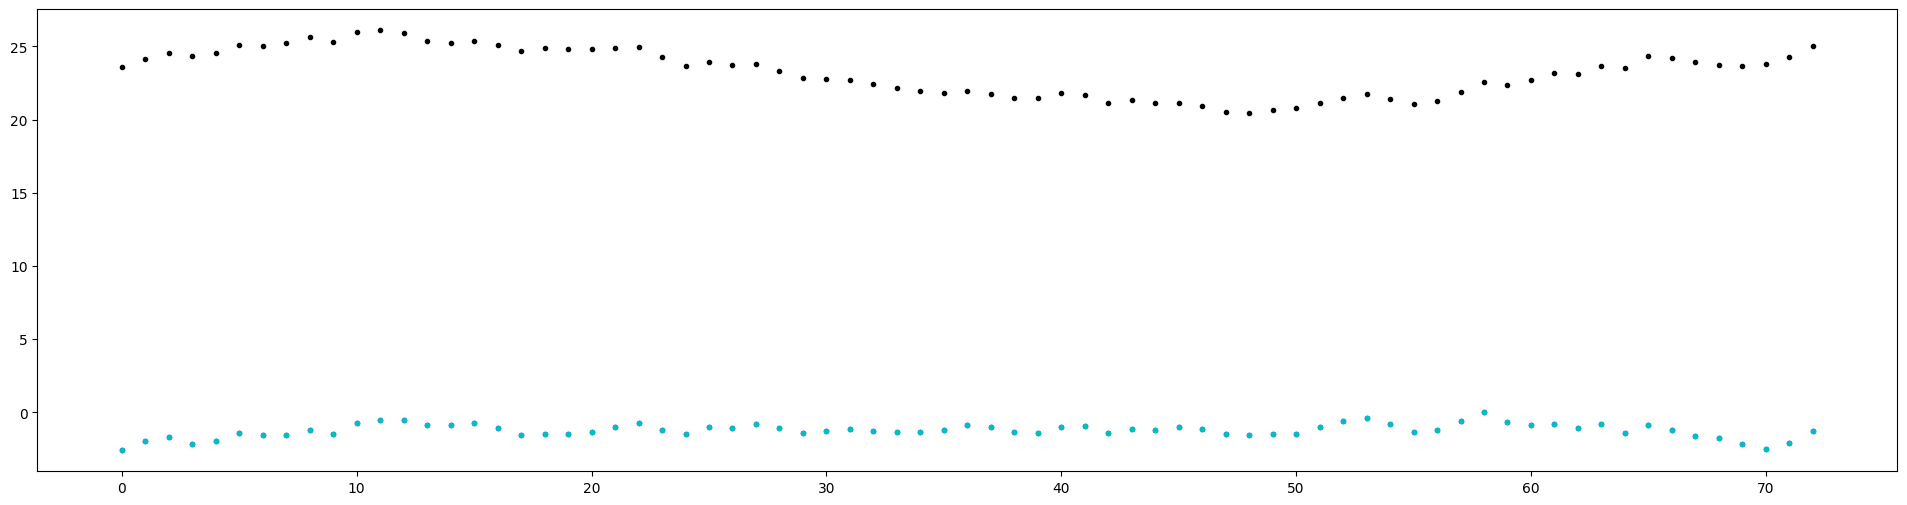

In [17]:
fig,ax=plt.subplots(1,1,figsize=(24,6))
ax.plot(forig.sst.values[:73,jj+5,180],'k.')
ax.plot(forig.sst.values[:73,jj+5,180]-fclim1.sst.values[:,jj+5,180],'b.');
ax.plot(fanom2.sst_an.values[:73,5,180],'c.')

In [22]:
b=lsqfit_md_detr_calcb(fanom2.sst_an.values)

In [23]:
b

array([[-7.00224188e-01, -7.50080789e-01, -7.32735051e-01, ...,
                    nan,             nan,             nan],
       [ 2.79999067e-04,  2.86027244e-04,  2.85482407e-04, ...,
                    nan,             nan,             nan]],
      shape=(2, 21600))

In [24]:
tref=fanom2.time.values[0]
fbout=fnameOISSTDetrFit(climyrs,jj,smoothClim,meth,win,L)
b=np.reshape(b,tuple([2]+list(fanom2.sst_an.values.shape)[1:]))

In [25]:
b.shape

(2, 60, 360)

In [26]:
dsb=xr.Dataset(data_vars={'fit':(['b','lat','lon'],b),'tref':tref},
                   coords={'b':np.arange(0,2),
                           'lat':fanom2.lat,
                           'lon':fanom2.lon})
dsb

<xarray.Dataset> Size: 347kB
Dimensions:  (b: 2, lat: 60, lon: 360)
Coordinates:
  * b        (b) int64 16B 0 1
  * lat      (lat) float32 240B -29.5 -28.5 -27.5 -26.5 ... 26.5 27.5 28.5 29.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    fit      (b, lat, lon) float64 346kB -0.7002 -0.7501 -0.7327 ... nan nan nan
    tref     object 8B 1993-01-03 12:00:00

In [27]:
dsb.tref.values

array(cftime.DatetimeNoLeap(1993, 1, 3, 12, 0, 0, 0, has_year_zero=True),
      dtype=object)

In [28]:
offset=(fanom.time.values[0]-tref).total_seconds()/(24*3600*L)

In [29]:
sst_an=lsqfit_md_detr_applyb(fanom2.sst_an.values,b,0)

In [30]:
sst_an.shape

(2190, 60, 360)

In [57]:
fclim0.lat.values[jj+5],fclim0.lon.values[180]

(np.float32(-24.5), np.float32(180.5))

In [58]:
fanom2.lat.values[5],fanom2.lon.values[180]

(np.float32(-24.5), np.float32(180.5))

In [19]:
an0=forig.sst.values[:,jj+5,180]-np.tile(fclim0.sst.values[:,jj+5,180],(int(len(fanom2.sst_an[:,5,180])/len(fclim0.sst[:,jj+5,180]))))

In [20]:
an1=forig.sst.values[:,65,180]-np.tile(fclim1.sst.values[:,65,180],(int(len(fanom2.sst_an[:,5,180])/len(fclim1.sst[:,65,180]))))

In [34]:
slope, intercept = np.polyfit(np.arange(0,len(an1)), an1, 1)
slope, intercept

(np.float64(0.00032591007374222034), np.float64(-0.8457499111085194))

In [36]:
slope, intercept = np.polyfit(np.arange(0,len(an1)), forig.sst.values[:,jj+5,180], 1)
slope, intercept

(np.float64(0.00027899978634586054), np.float64(23.685702495653214))

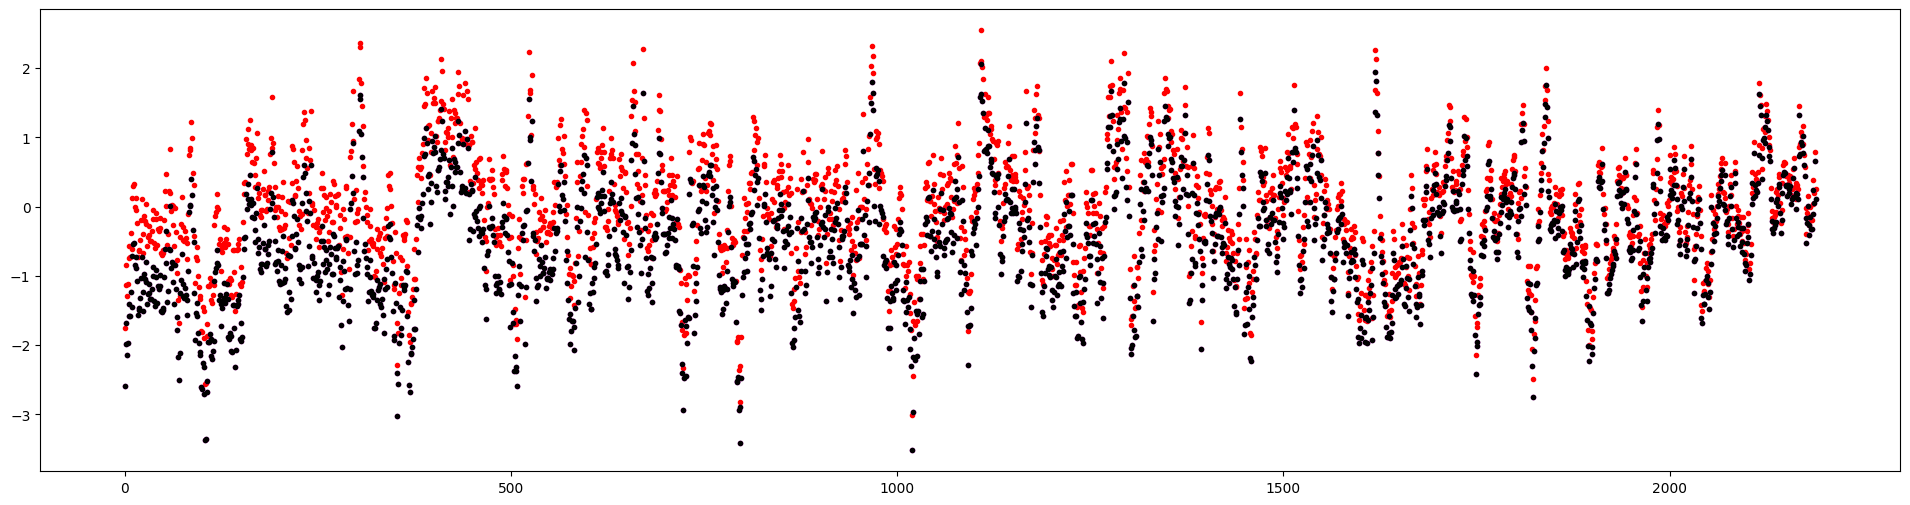

In [33]:
fig,ax=plt.subplots(1,1,figsize=(24,6))
ax.plot(sst_an[:,5,180],'r.')
ax.plot(fanom2.sst_an[:,5,180],'m.')
ax.plot(an1,'k.')

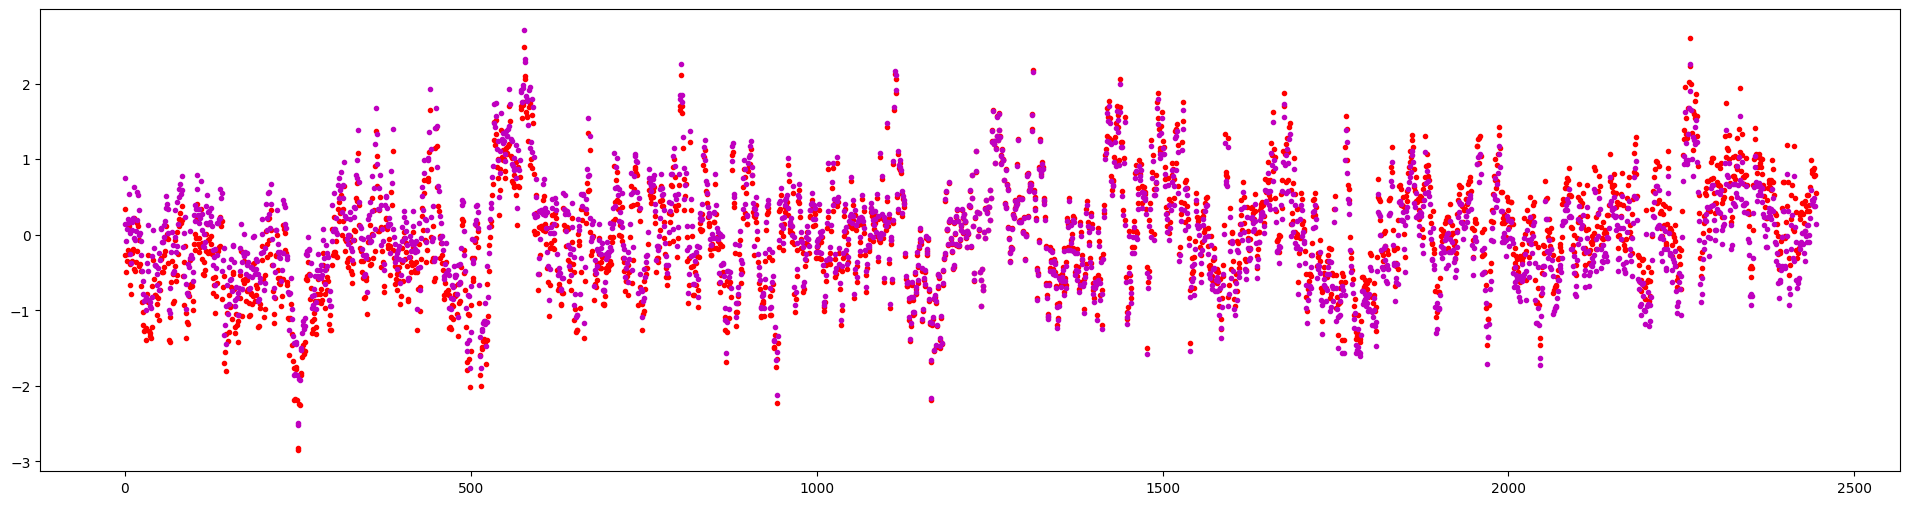

In [10]:
fig,ax=plt.subplots(1,1,figsize=(24,6))
ax.plot(fanom.sst_an[:,5,180],'r.')
ax.plot(fanomD.sst_an[:,5,180],'m.')

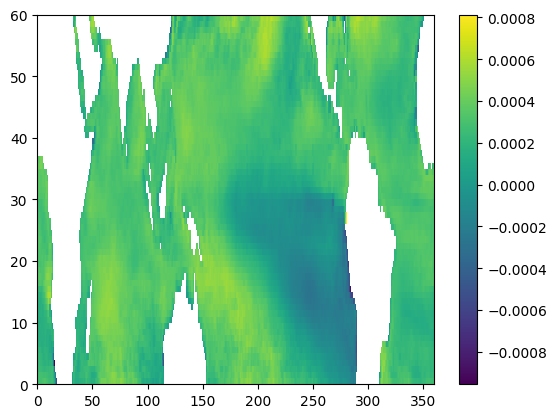

In [33]:
plt.pcolormesh(b[1,:,:])
plt.colorbar()

In [28]:
np.mean(fanom2.sst_an[:,5,180].values)

np.float64(-0.48904133539765937)

In [30]:
np.mean(sst_an[:,5,180])

np.float64(-1.1355705822650004e-17)

In [ ]:
sst_an=lsqfit_md_detr(fanom.sst_an.values)
fout=fnameOISSTAnom([ylimlistobs[0][0],ylimlistobs[-1][-1]],climyrs, jj, smoothClim, meth, win,L,detrended=True)

In [3]:
flist=['/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S1993010100_ocean_5d_surface_tso.nc',
       '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S1994010100_ocean_5d_surface_tso.nc',
       '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S1995010100_ocean_5d_surface_tso.nc',
       '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S1996010100_ocean_5d_surface_tso.nc',
       '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S1997010100_ocean_5d_surface_tso.nc',
       '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S1998010100_ocean_5d_surface_tso.nc',
       '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S1999010100_ocean_5d_surface_tso.nc',
       '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S2000010100_ocean_5d_surface_tso.nc',
       '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S2001010100_ocean_5d_surface_tso.nc',
       '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S2002010100_ocean_5d_surface_tso.nc',
       '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S2003010100_ocean_5d_surface_tso.nc',
       '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S2004010100_ocean_5d_surface_tso.nc',
       '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S2005010100_ocean_5d_surface_tso.nc',
       '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S2006010100_ocean_5d_surface_tso.nc',
       '/fs/site7/eccc/crd/cccma/users/reo000/data/predictions/cansipsv3_daily/CanESM5/joined/cwao_CanESM5.1p1bc-v20240611_hindcast_S2007010100_ocean_5d_surface_tso.nc']

In [6]:
cluster= LocalCluster(n_workers=4,threads_per_worker=1,dashboard_address='localhost:54924') # LocalCluster can be used as long as you are only running on a single node
#cluster= LocalCluster(memory_limit='8GB',n_workers=4,processes=True,dashboard_address='localhost:54924',) #
client=Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:54924/status,
Dashboard: http://127.0.0.1:54924/status,Workers: 4
Total threads: 4,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:27761,Workers: 0
Dashboard: http://127.0.0.1:54924/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:22737,Total threads: 1
Dashboard: http://127.0.0.1:17619/status,Memory: 251.60 GiB
Nanny: tcp://127.0.0.1:19165,


In [14]:
f0=xr.open_dataset('/fs/site7/eccc/crd/cccma/users/reo000/work/MHW_5d/clim/clim_cwao_CanESM5.1p1bc-v20240611_hindcast_C1993_2022_Mon06_ocean_5d_surface_tso.nc',decode_times=False)

In [15]:
f1=xr.open_dataset('/fs/site7/eccc/crd/cccma/users/reo000/work/MHW_5d/clim/clim_smooth_tri10_cwao_CanESM5.1p1bc-v20240611_hindcast_C1993_2022_Mon06_ocean_5d_surface_tso.nc',decode_times=False)

In [16]:
f1

<xarray.Dataset> Size: 22MB
Dimensions:   (leadtime: 43, lat: 180, lon: 360)
Coordinates:
  * leadtime  (leadtime) float64 344B 63.0 183.0 303.0 ... 4.983e+03 5.103e+03
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    tso       (leadtime, lat, lon) float64 22MB ...

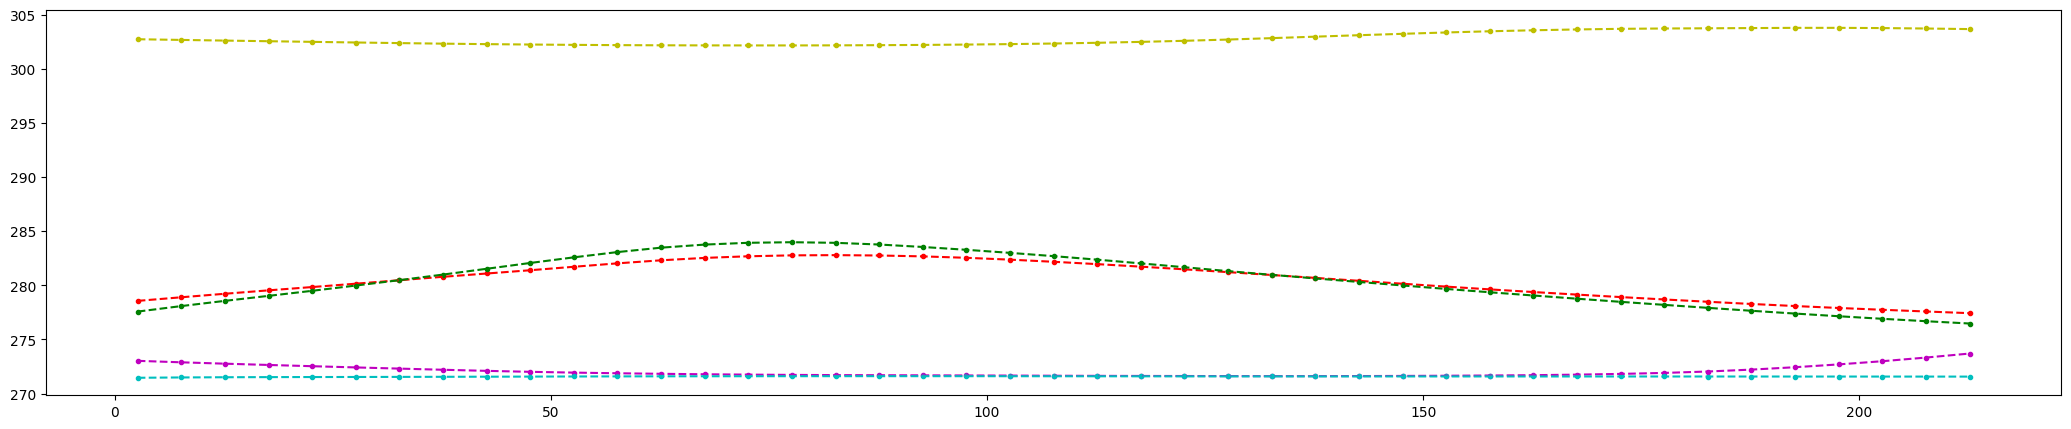

In [17]:
fig,ax=plt.subplots(1,1,figsize=(26,5))
ax.plot(f0.leadtime/24,f0.tso[:,142,180],'r.')
ax.plot(f0.leadtime/24,f0.tso[:,25,180],'m.')
ax.plot(f0.leadtime/24,f0.tso[:,80,180],'y.')
ax.plot(f0.leadtime/24,f0.tso[:,140,310],'g.')
ax.plot(f0.leadtime/24,f0.tso[:,170,220],'c.')
ax.plot(f1.leadtime/24,f1.tso[:,142,180],'r--')
ax.plot(f1.leadtime/24,f1.tso[:,25,180],'m--')
ax.plot(f1.leadtime/24,f1.tso[:,80,180],'y--')
ax.plot(f1.leadtime/24,f1.tso[:,140,310],'g--')
ax.plot(f1.leadtime/24,f1.tso[:,170,220],'c--')

In [3]:
test=xr.open_dataset('/fs/site7/eccc/crd/cccma/users/reo000/work/MHW_5d/OISST/oisst_anom_detr_ClimStri10_C1993_2022-avhrr-v02r01.regridded1x1g2.5day.1991_2024_j120.nc')

In [4]:
test

<xarray.Dataset> Size: 44MB
Dimensions:  (time: 255, lat: 60, lon: 360)
Coordinates:
  * time     (time) object 2kB 2021-01-03 12:00:00 ... 2024-06-27 12:00:00
  * lat      (lat) float32 240B 30.5 31.5 32.5 33.5 34.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    sst_an   (time, lat, lon) float64 44MB ...

In [5]:
test.time

<xarray.DataArray 'time' (time: 255)> Size: 2kB
array([cftime.DatetimeNoLeap(2021, 1, 3, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2021, 1, 8, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2021, 1, 13, 12, 0, 0, 0, has_year_zero=True),
       ...,
       cftime.DatetimeNoLeap(2024, 6, 17, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2024, 6, 22, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2024, 6, 27, 12, 0, 0, 0, has_year_zero=True)],
      shape=(255,), dtype=object)
Coordinates:
  * time     (time) object 2kB 2021-01-03 12:00:00 ... 2024-06-27 12:00:00
Attributes:
    long_name:     Center time of the day
    cell_methods:  time: mean